In [ ]:
import h5py
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True
import numpy as np
import os
import pandas as pd
import rootutils
from tqdm import tqdm

import torch

root = rootutils.setup_root(
    search_from=".",   # or __file__ in scripts
    indicator=".project-root",
    pythonpath=True
)

from src.utils.preprocess_utils import note_encode

In [ ]:
base_dir = "../../data/"
dali_ids_dir = os.path.join(base_dir, "./DALI_English_songs.csv")
dali_ids = pd.read_csv(dali_ids_dir)
dali_dev = dali_ids[dali_ids["split"] == "development"]["English_song_ids"].tolist()
print(f"Number of development songs: {len(dali_dev)}")

Number of development songs: 5764


In [3]:
dali_test = dali_ids[dali_ids["split"] == "test"]["English_song_ids"].tolist()
print(f"Number of test songs: {len(dali_test)}")

Number of test songs: 50


In [4]:
5764 + 50

5814

In [5]:
dali_feature_dir = os.path.join(base_dir, "DALI_features.hdf5")

note_features, sylphone_features = [], []
# Open the HDF5 file in read mode
with h5py.File(dali_feature_dir, 'r') as f:
    # Iterate through the keys in the HDF5 file
    for key in tqdm(f.keys()):
        if key not in dali_dev:
            continue
        # Append the data to the list
        note_features.append(torch.from_numpy(np.array(f[key]['note_encode'])).float())
        sylphone_features.append(torch.from_numpy(np.array(f[key]['sylphone_encode'])).float())

note_features = [note_encode(item) for item in note_features]

note_all = torch.cat(note_features, dim=0)[:, :-1]  # remove line information
syl_all = torch.cat(sylphone_features, dim=0)[:, :-1]  # remove line information
# get rid of word index
syl_all = torch.from_numpy(np.delete(syl_all.numpy(), -1, axis=-1))  # remove the first column which is word index
print(note_all.shape, syl_all.shape)

100%|██████████| 5776/5776 [00:03<00:00, 1747.22it/s]


torch.Size([2013142, 177]) torch.Size([1838452, 43])


In [6]:
def order_elements_with_occurrences(sequence):
    """
    Order elements in a sequence based on their occurrences.
    Args:
        sequence (torch.Tensor): A 2D tensor where each column represents a feature vector.
    Returns:
        tuple: A tuple containing:
            - note_occurrences (list): List of elements, repeated with their occurrences.
            - note_unique (torch.Tensor): Unique elements in the sequence.
            - note_counts (torch.Tensor): Counts of each unique element.
    """

    # Transpose to make columns into rows, then flatten each column as a row for uniqueness check
    flattened = sequence.T  # Shape: (num_columns, num_rows)
    element_unique, _, counts = torch.unique(flattened, dim=1, return_inverse=True, return_counts=True)
    # Transpose back if you want columns as columns
    element_unique = element_unique.T

    counts, idx = torch.sort(counts)
    element_unique = element_unique[idx,:]
    counts = counts.flip(0)
    element_unique = element_unique.flip(0)

    labels = torch.arange(len(element_unique)).tolist()
    occurrences = []

    for k in range(len(labels)):
        occurrences.extend([labels[k]] * counts[k])

    return occurrences, element_unique, counts

note_occurrences, note_unique_dev, note_counts = order_elements_with_occurrences(note_all)
syl_occurrences, syl_unique_dev, syl_counts = order_elements_with_occurrences(syl_all)

note_unique_map_dev = {k: [item[0], item[1].item()] for k, item in enumerate(zip(note_unique_dev, note_counts))}
syl_unique_map_dev = {k: [item[0], item[1].item()] for k, item in enumerate(zip(syl_unique_dev, syl_counts))}
print(len(note_unique_map_dev), len(syl_unique_map_dev))

10651 1907


Percent of notes kept: 0.9963
Percent of syls kept: 0.9992
7246 1156


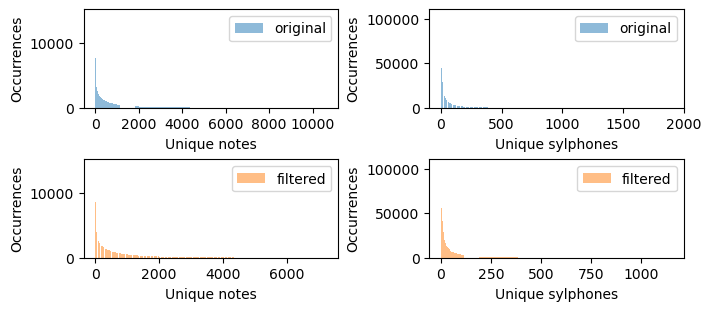

In [ ]:
min_note_count = 10
percent_keep_note = torch.sum(note_counts[note_counts > min_note_count]) / torch.sum(note_counts)

print(f"Percent of notes kept: {percent_keep_note:.4f}")


min_syl_count = 10
percent_keep_syl = torch.sum(syl_counts[syl_counts > min_syl_count]) / torch.sum(syl_counts)
unique_thresh_syl = torch.sum(syl_counts > min_syl_count)

print(f"Percent of syls kept: {percent_keep_syl:.4f}")

note_unique_map_keep = {k: v for k, v in note_unique_map_dev.items() if v[1] > min_note_count}
syl_unique_map_keep = {k: v for k, v in syl_unique_map_dev.items() if v[1] > min_syl_count}

print(len(note_unique_map_keep), len(syl_unique_map_keep))

note_counts_new = torch.tensor([v[1] for k, v in note_unique_map_keep.items()])
syl_counts_new = torch.tensor([v[1] for k, v in syl_unique_map_keep.items()])

# Plot histogram
visual_range = -1  # Limit the range for visualization
plt.figure(figsize=(7, 3))
plt.subplot(2, 2, 1)
plt.bar(torch.arange(len(note_counts[:visual_range])), note_counts[:visual_range], color="tab:blue", alpha=0.5, label='original')
plt.xlabel('Unique notes')
plt.ylabel('Occurrences')
plt.legend()
plt.subplot(2, 2, 2)
plt.bar(torch.arange(len(syl_counts[:visual_range])), syl_counts[:visual_range], color="tab:blue", alpha=0.5, label='original')
plt.xlabel('Unique sylphones')
plt.ylabel('Occurrences')
plt.legend()
plt.subplot(2, 2, 3)
plt.bar(torch.arange(len(note_counts_new[:visual_range])), note_counts_new[:visual_range], color="tab:orange", alpha=0.5, label='filtered')
plt.xlabel('Unique notes')
plt.ylabel('Occurrences')
plt.legend()
plt.subplot(2, 2, 4)
plt.bar(torch.arange(len(syl_counts_new[:visual_range])), syl_counts_new[:visual_range], color="tab:orange", alpha=0.5, label='filtered')
plt.xlabel('Unique sylphones')
plt.ylabel('Occurrences')
plt.legend()
# plt.show()
plt.savefig("../outputs/note_syl_distribution.pdf", bbox_inches='tight')

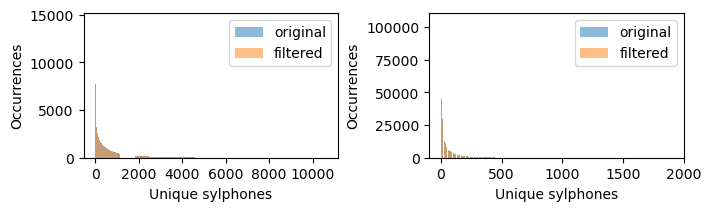

In [ ]:
# Plot histogram
visual_range = -1  # Limit the range for visualization
plt.figure(figsize=(7, 2))
plt.subplot(1, 2, 1)
plt.bar(torch.arange(len(note_counts[:visual_range])), note_counts[:visual_range], alpha=0.5, label='original')
plt.bar(torch.arange(len(note_counts_new[:visual_range])), note_counts_new[:visual_range], alpha=0.5, label='filtered')
plt.xlabel('Unique sylphones')
plt.ylabel('Occurrences')
plt.legend()
plt.subplot(1, 2, 2)
plt.bar(torch.arange(len(syl_counts[:visual_range])), syl_counts[:visual_range], alpha=0.5, label='original')
plt.bar(torch.arange(len(syl_counts_new[:visual_range])), syl_counts_new[:visual_range], alpha=0.5, label='filtered')
plt.xlabel('Unique sylphones')
plt.ylabel('Occurrences')
plt.legend()

In [9]:
note_unique_set = torch.stack([v[0] for v in note_unique_map_keep.values()])
syl_unique_set = torch.stack([v[0] for v in syl_unique_map_keep.values()])

np.savez("../outputs/unique_set_note_sylnoFront_min5.npz", note_unique=note_unique_set.numpy(), syl_unique=syl_unique_set.numpy())

In [ ]:
note_all_llen, syl_all_llen = [], []
for note_seq, syl_seq in zip(note_features, sylphone_features):
    note_line_idx = torch.cat((torch.tensor([-1]), torch.nonzero(note_seq[:,-1] == 1).squeeze(-1)))
    syl_line_idx = torch.cat((torch.tensor([-1]), torch.nonzero(syl_seq[:,-1] == 1).squeeze(-1)))

    assert len(note_line_idx) == len(syl_line_idx)

    note_lines = [note_seq[note_line_idx[k]+1:note_line_idx[k+1]+1] for k in range(len(note_line_idx)-1)]
    syl_lines = [syl_seq[syl_line_idx[k]+1:syl_line_idx[k+1]+1] for k in range(len(syl_line_idx)-1)]

    note_all_llen.extend([len(line) for line in note_lines])
    syl_all_llen.extend([len(line) for line in syl_lines])

note_all_llen = torch.tensor(note_all_llen).float()
syl_all_llen = torch.tensor(syl_all_llen).float()
print(f"Note line length: {torch.mean(note_all_llen):.2f} +/- {torch.std(note_all_llen):.2f}")
print(f"Syl line length: {torch.mean(syl_all_llen):.2f} +/- {torch.std(syl_all_llen):.2f}")

Note line length: 6.35 +/- 2.56
Syl line length: 5.80 +/- 2.43


Note line length quantiles: tensor([ 3., 11.])
Sylphone line length quantiles: tensor([ 2., 10.])


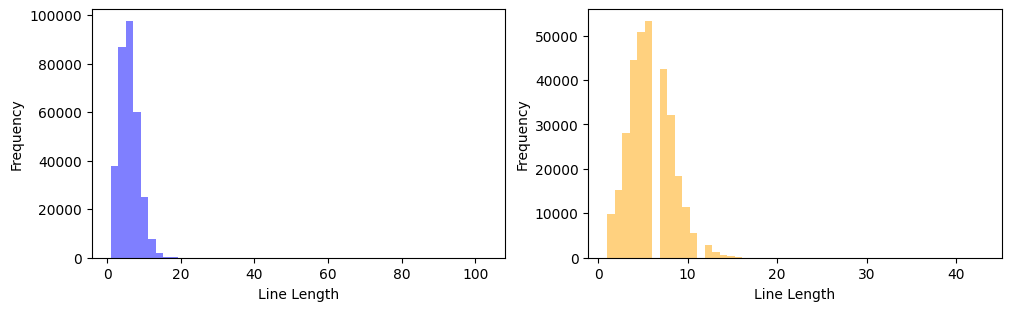

In [8]:
# Plot histogram of line lengths
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.hist(note_all_llen.numpy(), bins=50, color='blue', alpha=0.5, label='note line lengths')
plt.xlabel('Line Length')
plt.ylabel('Frequency')     
plt.subplot(1, 2, 2)
plt.hist(syl_all_llen.numpy(), bins=50, color='orange', alpha=0.5, label='sylphone line lengths')
plt.xlabel('Line Length')
plt.ylabel('Frequency')
# plt.show()
# plt.savefig("../outputs/note_syl_line_lengths.pdf", bbox_inches='tight')

# print 0.05 and 0.95 quantiles of note_all_llen and syl_all_llen
note_quantiles = torch.quantile(note_all_llen, torch.tensor([0.05, 0.95]))
syl_quantiles = torch.quantile(syl_all_llen, torch.tensor([0.05, 0.95]))
print(f"Note line length quantiles: {note_quantiles}")
print(f"Sylphone line length quantiles: {syl_quantiles}")